# RF switch test: AM sidebands from a chopped 2.5 GHz carrier

Sanity check for the ZYSWA-2-50DR+ RF switch before trusting it in a real sequence:
drive its TTL control input (AWG CH2) with a 10% duty cycle square wave, gating a
2.5 GHz CW microwave carrier on and off, and look at the result on the spectrum
analyzer. A switch that's actually chopping the carrier as commanded should show a
carrier line plus a comb of sidebands spaced at multiples of the chop frequency, with
relative amplitudes following the Fourier series of a 10% duty cycle pulse train
(|sinc(n * duty_cycle)|) -- if the switch weren't actually modulating anything (stuck
in one state, or CH2 not reaching the control pin), you'd just see a single CW line
with no sidebands at all.

**Physical setup for this test:** microwave source -> ZYSWA RF IN, RF2 (the "sample"
path, HIGH-selected) -> spectrum analyzer input DIRECTLY (not through the resonator or
amplifier) -- this is a bench characterization of the switch itself, so keep
`drive_power_dbm` conservative (default -20 dBm) since it feeds the analyzer directly.
AWG CH2 -> switch Control pin, +-5V bench supply already powering the switch's driver
(see notes.md for the grounding setup).

In [19]:
import sys

import numpy as np
import matplotlib.pyplot as plt

# This notebook lives in experiment/tests/ -- the driver modules
# (ks33600a.py, hp8673h.py, e4403b.py) are one level up, in
# experiment/ itself. Using an absolute path here rather than a
# cwd-relative ".." since Jupyter's kernel working directory depends
# on how/where it was launched from, not necessarily this notebook's
# own file location.
sys.path.insert(0, r"C:\Users\codin\Documents\projects\diamonds\experiment")

import ks33600a
from hp8673h import HP8673H
from e4403b import E4403B

AWG_RESOURCE = "USB0::0x0957::0x5707::MY53800810::INSTR"
GEN_RESOURCE = "GPIB1::19::INSTR"
SA_RESOURCE = "GPIB0::18::INSTR"

CARRIER_HZ = 2.5e9
DRIVE_POWER_DBM = -20.0  # conservative -- feeds the analyzer directly, no amplifier
CHOP_FREQ_HZ = 1000.0
DUTY_CYCLE_PCT = 10.0

awg = ks33600a.KS33600A(AWG_RESOURCE, debug=True)
sa = E4403B(SA_RESOURCE)
gen = HP8673H(GEN_RESOURCE)



Keysight 33600A: connected
*RST => +0,"No error"
*CLS => +0,"No error"
SOUR1:DATA:VOL:CLE => +0,"No error"
SOUR2:DATA:VOL:CLE => +0,"No error"
E4403B: connected
HP8673H: connected


## Configure the AWG's CH2 gate signal

Standard function-generator square wave with a programmable duty cycle (not a
DATA:SEQ arb sequence this time -- no need for one, since this is just a free-running
periodic gate, not synchronized to anything else). 0-5V swing into a high-impedance
load (the switch's CMOS control input), same convention as `pulsed_odmr.py`.

In [20]:

awg.write("SOUR2:FUNC SQU")
awg.write(f"SOUR2:FUNC:SQU:DCYCle {DUTY_CYCLE_PCT}")
awg.write(f"SOUR2:FREQ {CHOP_FREQ_HZ}")
awg.write("OUTP2:LOAD INF")
awg.write("SOUR2:VOLT:UNIT VPP")
awg.write("SOUR2:VOLT 5.0")
awg.write("SOUR2:VOLT:OFFS 2.5")
awg.write("TRIG2:SOUR IMM")
awg.write("OUTPUT2 ON")

print(f"CH2: {DUTY_CYCLE_PCT:.0f}% duty cycle square wave @ {CHOP_FREQ_HZ:.0f} Hz, "
      f"0-5V into high-Z")

SOUR2:FUNC SQU => +0,"No error"
SOUR2:FUNC:SQU:DCYCle 10.0 => +0,"No error"
SOUR2:FREQ 1000.0 => +0,"No error"
OUTP2:LOAD INF => +0,"No error"
SOUR2:VOLT:UNIT VPP => +0,"No error"
SOUR2:VOLT 5.0 => +0,"No error"
SOUR2:VOLT:OFFS 2.5 => +0,"No error"
TRIG2:SOUR IMM => +0,"No error"
OUTPUT2 ON => +0,"No error"
CH2: 10% duty cycle square wave @ 1000 Hz, 0-5V into high-Z


## Set the microwave source to CW

In [ ]:
gen.preset()
gen.set_frequency_hz(CARRIER_HZ)
gen.set_power_dbm(DRIVE_POWER_DBM)
gen.rf_on()

print(f"generator: CW {CARRIER_HZ/1e9:.4f} GHz @ {DRIVE_POWER_DBM} dBm, RF on")

HP8673H: connected
generator: CW 2.5000 GHz @ -20.0 dBm, RF on


## Capture the spectrum

Span wide enough to see several sidebands each side of the carrier; RBW narrow enough
to resolve individual comb lines (well below the chop frequency spacing).

In [ ]:
N_SIDEBANDS = 10
SPAN_HZ = 2 * N_SIDEBANDS * CHOP_FREQ_HZ
RBW_HZ = CHOP_FREQ_HZ / 20

sa.set_center_span(CARRIER_HZ, SPAN_HZ)
sa.write(f"BAND {RBW_HZ}")
sa.setup_averaging(count=10)
sa.single_sweep(n=10)
freqs_hz, power_dbm = sa.get_trace(1)

np.save("rf_switch_test_freqs_hz.npy", freqs_hz)
np.save("rf_switch_test_power_dbm.npy", power_dbm)

print(f"captured {len(freqs_hz)} points, {freqs_hz.min()/1e9:.6f}-{freqs_hz.max()/1e9:.6f} GHz, "
      f"RBW {RBW_HZ:.1f} Hz -- saved rf_switch_test_freqs_hz.npy, "
      f"rf_switch_test_power_dbm.npy")

E4403B: connected
captured 401 points, 2.499990-2.500010 GHz, RBW 50.0 Hz -- saved rf_switch_test_freqs_hz.npy, rf_switch_test_power_dbm.npy


## Plot vs. the expected sideband pattern

Idealized comparison: treat the switch as a perfect on/off gate with the given duty
cycle (ignoring finite isolation -- the datasheet gives ~17-20 dB isolation around
2.5 GHz, so the "off" state isn't perfectly zero, which will shift the real sideband
floor up somewhat relative to this ideal comparison). For an ideal rectangular pulse
train, the n-th harmonic's relative amplitude is `duty_cycle * sinc(n * duty_cycle)`
(sinc(x) = sin(pi*x)/(pi*x)), referenced to the amplitude a fully-on (unchopped)
carrier would show.

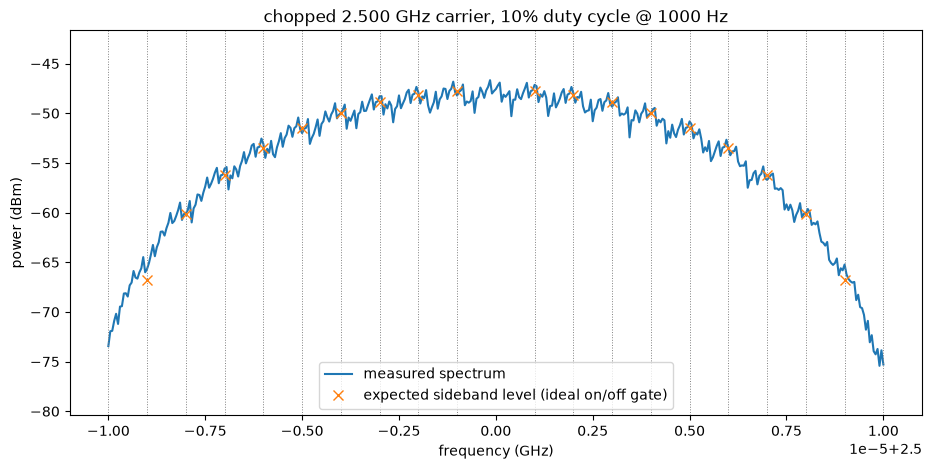

carrier line: -47.57 dBm at 2.500000 GHz
measured trace spans -75.43 to -46.67 dBm (28.75 dB peak-to-peak ripple)


In [13]:
duty = DUTY_CYCLE_PCT / 100
harmonics_n = np.arange(-N_SIDEBANDS, N_SIDEBANDS + 1)
harmonics_n = harmonics_n[harmonics_n != 0]  # DC/carrier term handled separately
expected_freqs_hz = CARRIER_HZ + harmonics_n * CHOP_FREQ_HZ
expected_rel_amplitude = duty * np.abs(np.sinc(harmonics_n * duty))  # np.sinc is normalized: sin(pi x)/(pi x)
expected_rel_dbc = 20 * np.log10(expected_rel_amplitude / duty)  # relative to the carrier line itself

carrier_idx = np.argmin(np.abs(freqs_hz - CARRIER_HZ))
carrier_dbm = power_dbm[carrier_idx]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(freqs_hz / 1e9, power_dbm, color="C0", label="measured spectrum")

for f, rel_dbc in zip(expected_freqs_hz, expected_rel_dbc):
    ax.axvline(f / 1e9, color="gray", ls=":", lw=0.7)
ax.plot(expected_freqs_hz / 1e9, carrier_dbm + expected_rel_dbc, "x", color="C1", ms=7,
        label="expected sideband level (ideal on/off gate)")

# Zoom the y-axis to the MEASURED data's own range (with margin) -- the ideal
# model's null markers (theoretically ~-inf dB at the sinc zeros) would otherwise
# blow up the scale and squash the real structure into an unreadable sliver.
y_margin = 5
ax.set_ylim(power_dbm.min() - y_margin, power_dbm.max() + y_margin)

ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("power (dBm)")
ax.set_title(f"chopped {CARRIER_HZ/1e9:.3f} GHz carrier, {DUTY_CYCLE_PCT:.0f}% duty cycle "
             f"@ {CHOP_FREQ_HZ:.0f} Hz")
ax.legend()
plt.show()

print(f"carrier line: {carrier_dbm:.2f} dBm at {freqs_hz[carrier_idx]/1e9:.6f} GHz")
print(f"measured trace spans {power_dbm.min():.2f} to {power_dbm.max():.2f} dBm "
      f"({power_dbm.max()-power_dbm.min():.2f} dB peak-to-peak ripple)")

## Quantitative check: is there really a periodic comb, or does this just look like noise?

Rather than eyeballing the plot (easy to be fooled either way by a compressed
y-axis or by noise that happens to look wiggly), take the FFT of the trace itself
(power_dbm vs. frequency) and look for a peak at the specific periodicity a
CHOP_FREQ_HZ-spaced comb would produce -- 1 cycle of ripple every CHOP_FREQ_HZ in
the frequency axis. A real comb shows up as one strong, narrow peak there,
clearly above the background; pure noise (or a flat, unmodulated carrier) shows no
such standout peak -- the background level is what to compare it against, not zero.

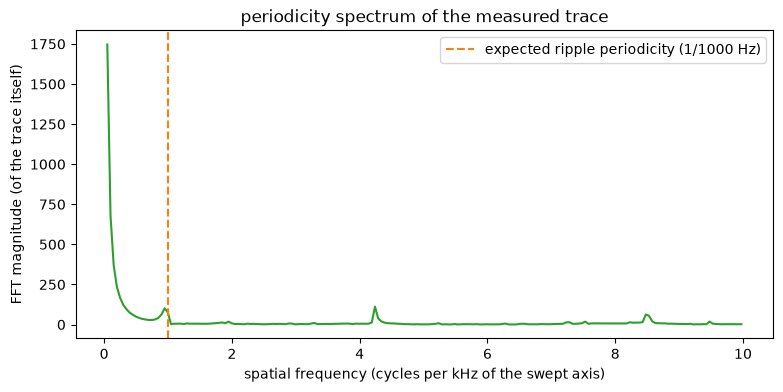

magnitude at the expected 1000 Hz-comb periodicity: 74.876
typical background level (median of other bins): 4.773
peak-to-background ratio: 15.7x
-> clear standout peak at the expected periodicity: real comb structure, not just noise


In [14]:
freq_step_hz = freqs_hz[1] - freqs_hz[0]
detrended = power_dbm - power_dbm.mean()
fft_mag = np.abs(np.fft.rfft(detrended))
fft_cycles_per_hz = np.fft.rfftfreq(len(detrended), d=freq_step_hz)

# Expected ripple periodicity: one full cycle every CHOP_FREQ_HZ in the frequency
# axis, i.e. a "spatial frequency" of 1/CHOP_FREQ_HZ cycles per Hz.
expected_cycles_per_hz = 1 / CHOP_FREQ_HZ
peak_idx = np.argmin(np.abs(fft_cycles_per_hz - expected_cycles_per_hz))

# Compare the magnitude AT that expected periodicity to the typical background
# level elsewhere in the spectrum (median of all other non-DC bins).
other_bins = np.delete(fft_mag, [0, peak_idx])
background_level = np.median(other_bins)
peak_level = fft_mag[peak_idx]
snr = peak_level / background_level if background_level > 0 else float("inf")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fft_cycles_per_hz[1:] * 1e3, fft_mag[1:], color="C2")
ax.axvline(expected_cycles_per_hz * 1e3, color="C1", ls="--",
           label=f"expected ripple periodicity (1/{CHOP_FREQ_HZ:.0f} Hz)")
ax.set_xlabel("spatial frequency (cycles per kHz of the swept axis)")
ax.set_ylabel("FFT magnitude (of the trace itself)")
ax.set_title("periodicity spectrum of the measured trace")
ax.legend()
plt.show()

print(f"magnitude at the expected {CHOP_FREQ_HZ:.0f} Hz-comb periodicity: {peak_level:.3f}")
print(f"typical background level (median of other bins): {background_level:.3f}")
print(f"peak-to-background ratio: {snr:.1f}x")
if snr > 3:
    print("-> clear standout peak at the expected periodicity: real comb structure, "
          "not just noise")
else:
    print("-> no clear standout peak: this looks more like noise than an actual "
          "chopped-carrier comb -- the switch may not be modulating as expected")

## Second test: 1 MHz chop, 50% duty cycle

50% duty cycle gives the classic symmetric square wave spectrum -- its Fourier
series contains ONLY ODD harmonics (every even harmonic is exactly zero), unlike
the 10% duty case above where the sidebands decay slowly and nearly-uniformly out
to the first null at n=10. That alternating strong/null pattern, plus 1000x wider
sideband spacing (1 MHz vs. 1 kHz), should make the comb much easier to pick out
by eye. Reuses the same `awg`/`gen`/`sa` connections from above -- no need to
reconnect.

In [15]:
CHOP_FREQ_HZ_2 = 1e6
DUTY_CYCLE_PCT_2 = 50.0

awg.write("SOUR2:FUNC SQU")
awg.write(f"SOUR2:FUNC:SQU:DCYCle {DUTY_CYCLE_PCT_2}")
awg.write(f"SOUR2:FREQ {CHOP_FREQ_HZ_2}")

print(f"CH2: {DUTY_CYCLE_PCT_2:.0f}% duty cycle square wave @ {CHOP_FREQ_HZ_2/1e6:.1f} MHz")

SOUR2:FUNC SQU => +0,"No error"
SOUR2:FUNC:SQU:DCYCle 50.0 => +0,"No error"
SOUR2:FREQ 1000000.0 => +0,"No error"
CH2: 50% duty cycle square wave @ 1.0 MHz


### Capture and check

In [16]:
N_SIDEBANDS_2 = 10
SPAN_HZ_2 = 2 * N_SIDEBANDS_2 * CHOP_FREQ_HZ_2
RBW_HZ_2 = CHOP_FREQ_HZ_2 / 20

sa.set_center_span(CARRIER_HZ, SPAN_HZ_2)
sa.write(f"BAND {RBW_HZ_2}")
sa.setup_averaging(count=10)
sa.single_sweep(n=10)
freqs_hz_2, power_dbm_2 = sa.get_trace(1)

np.save("rf_switch_test_1mhz_freqs_hz.npy", freqs_hz_2)
np.save("rf_switch_test_1mhz_power_dbm.npy", power_dbm_2)

print(f"captured {len(freqs_hz_2)} points, {freqs_hz_2.min()/1e9:.5f}-{freqs_hz_2.max()/1e9:.5f} GHz, "
      f"RBW {RBW_HZ_2/1e3:.1f} kHz -- saved rf_switch_test_1mhz_freqs_hz.npy, "
      f"rf_switch_test_1mhz_power_dbm.npy")

captured 401 points, 2.49000-2.51000 GHz, RBW 50.0 kHz -- saved rf_switch_test_1mhz_freqs_hz.npy, rf_switch_test_1mhz_power_dbm.npy


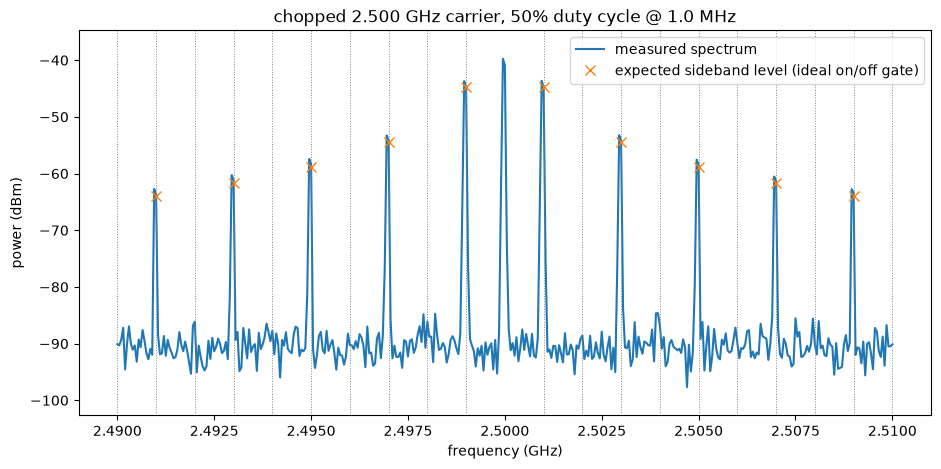

carrier line: -40.89 dBm at 2.500000 GHz
measured trace spans -97.68 to -39.77 dBm (57.91 dB peak-to-peak ripple)
note: even harmonics (n=+-2,4,6,8,10) should be exactly NULL for a 50% duty cycle -- look for alternating strong/weak sidebands rather than a uniform comb.


In [17]:
duty_2 = DUTY_CYCLE_PCT_2 / 100
harmonics_n_2 = np.arange(-N_SIDEBANDS_2, N_SIDEBANDS_2 + 1)
harmonics_n_2 = harmonics_n_2[harmonics_n_2 != 0]
expected_freqs_hz_2 = CARRIER_HZ + harmonics_n_2 * CHOP_FREQ_HZ_2
expected_rel_amplitude_2 = duty_2 * np.abs(np.sinc(harmonics_n_2 * duty_2))
expected_rel_dbc_2 = 20 * np.log10(expected_rel_amplitude_2 / duty_2)

carrier_idx_2 = np.argmin(np.abs(freqs_hz_2 - CARRIER_HZ))
carrier_dbm_2 = power_dbm_2[carrier_idx_2]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(freqs_hz_2 / 1e9, power_dbm_2, color="C0", label="measured spectrum")
for f, rel_dbc in zip(expected_freqs_hz_2, expected_rel_dbc_2):
    ax.axvline(f / 1e9, color="gray", ls=":", lw=0.7)
ax.plot(expected_freqs_hz_2 / 1e9, carrier_dbm_2 + expected_rel_dbc_2, "x", color="C1", ms=7,
        label="expected sideband level (ideal on/off gate)")

y_margin = 5
ax.set_ylim(power_dbm_2.min() - y_margin, power_dbm_2.max() + y_margin)
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("power (dBm)")
ax.set_title(f"chopped {CARRIER_HZ/1e9:.3f} GHz carrier, {DUTY_CYCLE_PCT_2:.0f}% duty cycle "
             f"@ {CHOP_FREQ_HZ_2/1e6:.1f} MHz")
ax.legend()
plt.show()

print(f"carrier line: {carrier_dbm_2:.2f} dBm at {freqs_hz_2[carrier_idx_2]/1e9:.6f} GHz")
print(f"measured trace spans {power_dbm_2.min():.2f} to {power_dbm_2.max():.2f} dBm "
      f"({power_dbm_2.max()-power_dbm_2.min():.2f} dB peak-to-peak ripple)")
print("note: even harmonics (n=+-2,4,6,8,10) should be exactly NULL for a 50% duty "
      "cycle -- look for alternating strong/weak sidebands rather than a uniform comb.")

### Quantitative periodicity check (1 MHz case)

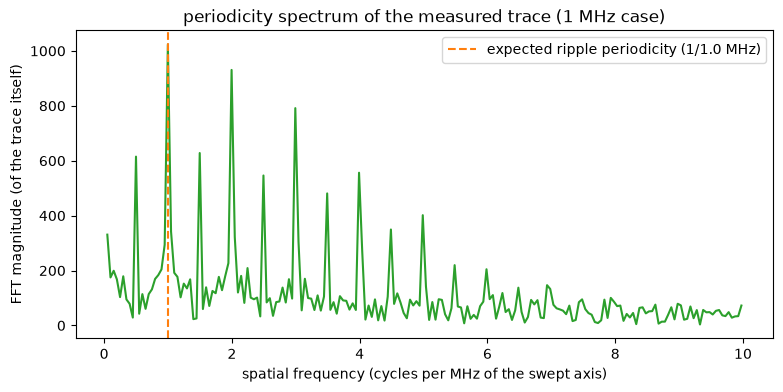

magnitude at the expected 1.0 MHz-comb periodicity: 1023.287
typical background level (median of other bins): 72.507
peak-to-background ratio: 14.1x
-> clear standout peak at the expected periodicity: real comb structure, not just noise


In [18]:
freq_step_hz_2 = freqs_hz_2[1] - freqs_hz_2[0]
detrended_2 = power_dbm_2 - power_dbm_2.mean()
fft_mag_2 = np.abs(np.fft.rfft(detrended_2))
fft_cycles_per_hz_2 = np.fft.rfftfreq(len(detrended_2), d=freq_step_hz_2)

expected_cycles_per_hz_2 = 1 / CHOP_FREQ_HZ_2
peak_idx_2 = np.argmin(np.abs(fft_cycles_per_hz_2 - expected_cycles_per_hz_2))

other_bins_2 = np.delete(fft_mag_2, [0, peak_idx_2])
background_level_2 = np.median(other_bins_2)
peak_level_2 = fft_mag_2[peak_idx_2]
snr_2 = peak_level_2 / background_level_2 if background_level_2 > 0 else float("inf")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fft_cycles_per_hz_2[1:] * 1e6, fft_mag_2[1:], color="C2")
ax.axvline(expected_cycles_per_hz_2 * 1e6, color="C1", ls="--",
           label=f"expected ripple periodicity (1/{CHOP_FREQ_HZ_2/1e6:.1f} MHz)")
ax.set_xlabel("spatial frequency (cycles per MHz of the swept axis)")
ax.set_ylabel("FFT magnitude (of the trace itself)")
ax.set_title("periodicity spectrum of the measured trace (1 MHz case)")
ax.legend()
plt.show()

print(f"magnitude at the expected {CHOP_FREQ_HZ_2/1e6:.1f} MHz-comb periodicity: {peak_level_2:.3f}")
print(f"typical background level (median of other bins): {background_level_2:.3f}")
print(f"peak-to-background ratio: {snr_2:.1f}x")
if snr_2 > 3:
    print("-> clear standout peak at the expected periodicity: real comb structure, "
          "not just noise")
else:
    print("-> no clear standout peak: this looks more like noise than an actual "
          "chopped-carrier comb -- the switch may not be modulating as expected")

## Third test: with the amplifier in the chain (1 MHz, 50% duty cycle)

Repeats the 1 MHz / 50% duty cycle test above, but with the amplifier now in its
real intended position: microwave source -> ZYSWA RF IN, RF2 (HIGH-selected) ->
amplifier -> spectrum analyzer input. RF1 -> a proper 50 ohm dummy load (absorptive
switch -- RF always goes somewhere; RF1 carries 90% of every cycle at 10% duty, or
50% at this test's 50% duty cycle). Reuses the same `awg`/`gen`/`sa` connections from
above.

**Power budget:** with the switch BEFORE the amplifier, the switch itself only ever
sees the raw (unamplified) generator output -- trivial relative to its +31 dBm rating
regardless of drive level, so that's not the binding constraint here. The amplifier's
OUTPUT feeding the analyzer is what needs care instead. The next cell computes a
deliberately pessimistic worst case (the amplifier's highest-ever-measured gain from
`new_amplifier_gain.ipynb`, combined with an assumed-zero cable loss between the
amplifier and the analyzer) and checks it against a target no more aggressive than the
-20 dBm used safely direct-into-the-analyzer in the no-amplifier tests above, refusing
to proceed if the margin isn't comfortably large.

In [21]:
# Worst-case power budget check -- run BEFORE any RF power change below.
DRIVE_POWER_DBM_3 = -60.0          # deliberately low -- amplifier is now in the chain
                                    # before the analyzer
MAX_MEASURED_AMP_GAIN_DB = 31.11    # highest gain ever measured across the amplifier's
                                    # whole characterized sweep (new_amplifier_gain.ipynb),
                                    # not the mean -- deliberately pessimistic
ASSUMED_CABLE_LOSS_DB = 0.0         # worst case: assume NO loss between amplifier and
                                    # analyzer, since the real cable loss isn't known
SAFE_TARGET_DBM = -20.0             # no more aggressive than the level already used
                                    # safely direct-into-the-analyzer above
MIN_REQUIRED_MARGIN_DB = 5.0

worst_case_analyzer_dbm = DRIVE_POWER_DBM_3 + MAX_MEASURED_AMP_GAIN_DB - ASSUMED_CABLE_LOSS_DB
margin_db = SAFE_TARGET_DBM - worst_case_analyzer_dbm

print(f"drive power:                {DRIVE_POWER_DBM_3:+.1f} dBm")
print(f"+ worst-case amp gain:      {MAX_MEASURED_AMP_GAIN_DB:+.2f} dB")
print(f"- assumed cable loss:       {ASSUMED_CABLE_LOSS_DB:.1f} dB (assumed zero, worst case)")
print(f"= worst-case analyzer input: {worst_case_analyzer_dbm:+.2f} dBm")
print(f"safety target:               {SAFE_TARGET_DBM:+.1f} dBm")
print(f"margin below target:         {margin_db:+.2f} dB")

assert margin_db >= MIN_REQUIRED_MARGIN_DB, (
    f"margin only {margin_db:.2f} dB (need >= {MIN_REQUIRED_MARGIN_DB} dB) -- "
    f"lower DRIVE_POWER_DBM_3 before proceeding"
)
print("\nmargin OK -- safe to proceed")

drive power:                -60.0 dBm
+ worst-case amp gain:      +31.11 dB
- assumed cable loss:       0.0 dB (assumed zero, worst case)
= worst-case analyzer input: -28.89 dBm
safety target:               -20.0 dBm
margin below target:         +8.89 dB

margin OK -- safe to proceed


### Configure and capture (1 MHz, 50% duty, amplifier in the chain)

In [22]:
CHOP_FREQ_HZ_3 = 1e6
DUTY_CYCLE_PCT_3 = 50.0

awg.write("SOUR2:FUNC SQU")
awg.write(f"SOUR2:FUNC:SQU:DCYCle {DUTY_CYCLE_PCT_3}")
awg.write(f"SOUR2:FREQ {CHOP_FREQ_HZ_3}")

gen.set_power_dbm(DRIVE_POWER_DBM_3)

print(f"CH2: {DUTY_CYCLE_PCT_3:.0f}% duty cycle square wave @ {CHOP_FREQ_HZ_3/1e6:.1f} MHz")
print(f"generator power: {DRIVE_POWER_DBM_3} dBm")

SOUR2:FUNC SQU => +0,"No error"
SOUR2:FUNC:SQU:DCYCle 50.0 => +0,"No error"
SOUR2:FREQ 1000000.0 => +0,"No error"
CH2: 50% duty cycle square wave @ 1.0 MHz
generator power: -60.0 dBm


In [24]:
N_SIDEBANDS_3 = 10
SPAN_HZ_3 = 2 * N_SIDEBANDS_3 * CHOP_FREQ_HZ_3
RBW_HZ_3 = CHOP_FREQ_HZ_3 / 20

sa.set_center_span(CARRIER_HZ, SPAN_HZ_3)
sa.write(f"BAND {RBW_HZ_3}")
sa.setup_averaging(count=10)
sa.single_sweep(n=10)
freqs_hz_3, power_dbm_3 = sa.get_trace(1)

np.save("rf_switch_test_amp_freqs_hz.npy", freqs_hz_3)
np.save("rf_switch_test_amp_power_dbm.npy", power_dbm_3)

print(f"captured {len(freqs_hz_3)} points, {freqs_hz_3.min()/1e9:.5f}-{freqs_hz_3.max()/1e9:.5f} GHz, "
      f"RBW {RBW_HZ_3/1e3:.1f} kHz -- saved rf_switch_test_amp_freqs_hz.npy, "
      f"rf_switch_test_amp_power_dbm.npy")

captured 401 points, 2.49000-2.51000 GHz, RBW 50.0 kHz -- saved rf_switch_test_amp_freqs_hz.npy, rf_switch_test_amp_power_dbm.npy


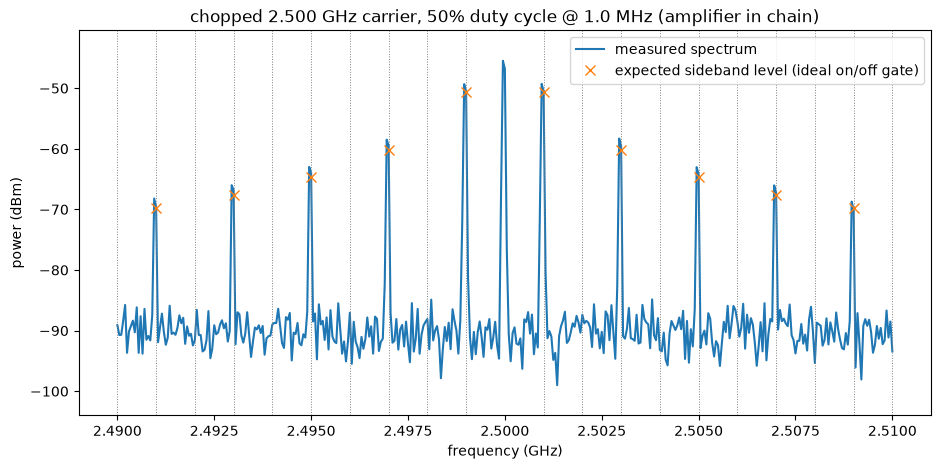

carrier line: -46.77 dBm at 2.500000 GHz
measured trace spans -99.01 to -45.48 dBm (53.53 dB peak-to-peak ripple)
note: even harmonics (n=+-2,4,6,8,10) should be exactly NULL for a 50% duty cycle -- look for alternating strong/weak sidebands rather than a uniform comb.


: 

In [ ]:
duty_3 = DUTY_CYCLE_PCT_3 / 100
harmonics_n_3 = np.arange(-N_SIDEBANDS_3, N_SIDEBANDS_3 + 1)
harmonics_n_3 = harmonics_n_3[harmonics_n_3 != 0]
expected_freqs_hz_3 = CARRIER_HZ + harmonics_n_3 * CHOP_FREQ_HZ_3
expected_rel_amplitude_3 = duty_3 * np.abs(np.sinc(harmonics_n_3 * duty_3))
expected_rel_dbc_3 = 20 * np.log10(expected_rel_amplitude_3 / duty_3)

carrier_idx_3 = np.argmin(np.abs(freqs_hz_3 - CARRIER_HZ))
carrier_dbm_3 = power_dbm_3[carrier_idx_3]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(freqs_hz_3 / 1e9, power_dbm_3, color="C0", label="measured spectrum")
for f, rel_dbc in zip(expected_freqs_hz_3, expected_rel_dbc_3):
    ax.axvline(f / 1e9, color="gray", ls=":", lw=0.7)
ax.plot(expected_freqs_hz_3 / 1e9, carrier_dbm_3 + expected_rel_dbc_3, "x", color="C1", ms=7,
        label="expected sideband level (ideal on/off gate)")

y_margin = 5
ax.set_ylim(power_dbm_3.min() - y_margin, power_dbm_3.max() + y_margin)
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("power (dBm)")
ax.set_title(f"chopped {CARRIER_HZ/1e9:.3f} GHz carrier, {DUTY_CYCLE_PCT_3:.0f}% duty cycle "
             f"@ {CHOP_FREQ_HZ_3/1e6:.1f} MHz (amplifier in chain)")
ax.legend()
plt.show()

print(f"carrier line: {carrier_dbm_3:.2f} dBm at {freqs_hz_3[carrier_idx_3]/1e9:.6f} GHz")
print(f"measured trace spans {power_dbm_3.min():.2f} to {power_dbm_3.max():.2f} dBm "
      f"({power_dbm_3.max()-power_dbm_3.min():.2f} dB peak-to-peak ripple)")
print("note: even harmonics (n=+-2,4,6,8,10) should be exactly NULL for a 50% duty "
      "cycle -- look for alternating strong/weak sidebands rather than a uniform comb.")

### Quantitative periodicity check (amplifier-in-chain case)

In [ ]:
freq_step_hz_3 = freqs_hz_3[1] - freqs_hz_3[0]
detrended_3 = power_dbm_3 - power_dbm_3.mean()
fft_mag_3 = np.abs(np.fft.rfft(detrended_3))
fft_cycles_per_hz_3 = np.fft.rfftfreq(len(detrended_3), d=freq_step_hz_3)

expected_cycles_per_hz_3 = 1 / CHOP_FREQ_HZ_3
peak_idx_3 = np.argmin(np.abs(fft_cycles_per_hz_3 - expected_cycles_per_hz_3))

other_bins_3 = np.delete(fft_mag_3, [0, peak_idx_3])
background_level_3 = np.median(other_bins_3)
peak_level_3 = fft_mag_3[peak_idx_3]
snr_3 = peak_level_3 / background_level_3 if background_level_3 > 0 else float("inf")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fft_cycles_per_hz_3[1:] * 1e6, fft_mag_3[1:], color="C2")
ax.axvline(expected_cycles_per_hz_3 * 1e6, color="C1", ls="--",
           label=f"expected ripple periodicity (1/{CHOP_FREQ_HZ_3/1e6:.1f} MHz)")
ax.set_xlabel("spatial frequency (cycles per MHz of the swept axis)")
ax.set_ylabel("FFT magnitude (of the trace itself)")
ax.set_title("periodicity spectrum of the measured trace (amplifier-in-chain case)")
ax.legend()
plt.show()

print(f"magnitude at the expected {CHOP_FREQ_HZ_3/1e6:.1f} MHz-comb periodicity: {peak_level_3:.3f}")
print(f"typical background level (median of other bins): {background_level_3:.3f}")
print(f"peak-to-background ratio: {snr_3:.1f}x")
if snr_3 > 3:
    print("-> clear standout peak at the expected periodicity: real comb structure, "
          "not just noise")
else:
    print("-> no clear standout peak: this looks more like noise than an actual "
          "chopped-carrier comb -- the switch may not be modulating as expected")

## Shutdown

In [19]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()
awg.write("OUTPUT2 OFF")
awg.close()

OUTPUT2 OFF => +0,"No error"
